<h1 style="text-align: center; font-family: Arial; font-weight: bold; color:green; font-size:36px;">Sentiment Analysis on Energy in the Republic Ireland and other European Countries</h1>
<p>
    Data are gathered through multiple Reddit Forums related to energy topics in Ireland using the authorized API, adhering to the website's policies and regulations.  
</p>

In [3]:
# Import Libraries
# API Requests
import requests
import json

#Accessing Environment Variables
import os

# Data Manipulation
import pandas as pd
import re

# Visualisation
import plotly.express as px

# Word processors
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from dotenv import load_dotenv
from wordcloud import WordCloud

# Model
from flair.models import TextClassifier

In [4]:
# Install nltk
#!pip install nltk

# Download stopwords and punkt
#nltk.download('punkt')
#nltk.download('stopwords')

#Install wordcloud
#!pip install wordcloud

In [5]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Load Credentials

In [7]:
# Load environment variables
load_dotenv()

# Get required credentials 
CLIENT_ID = os.getenv('CLIENT_ID')
CLIENT_SECRET = os.getenv('CLIENT_SECRET')
USERNAME = os.getenv('REDDIT_USERNAME')
PASSWORD = os.getenv('REDDIT_PASSWORD')
USER_AGENT= os.getenv('REDDIT_USERAGENT')

# Check all variables are loaded
if CLIENT_ID and CLIENT_SECRET and USERNAME and PASSWORD:
    print('Credentials Loaded!')
else:
    print('Error loading credentials!')

Credentials Loaded!


### Get Access Token

In [9]:
# Identify authentication method
data = {
    'grant_type': 'password',
    'username': USERNAME,
    'password': PASSWORD
}

# Authentication
auth = requests.auth.HTTPBasicAuth(CLIENT_ID, CLIENT_SECRET)

# Headers
headers = {'User-Agent': USER_AGENT}

# Get access token
res = requests.post('https://www.reddit.com/api/v1/access_token',
                    auth=auth, data=data, headers=headers)

# Check if response is valid
if res.status_code != 200:
    print("Token request failed:", res.text)
    exit()
else: 
    token = res.json()['access_token']

## Data Gathering

In [11]:
# List of all Reddit posts related to energy in Ireland which will be used to extract data
IE_POST_ID =[
    '1g6t908/electricity_bill/',
    '1b3qqxh/electricity_bill/',
    '12yqhv8/can_someone_eli5_why_our_electricity_prices_are/',
    '1exjvob/very_high_electricity_bill/',
    '1cuw7de/insane_electricity_usage/',
    '1k29se6/rise_in_electricity_costs_amid_move_from_fossil/',
    '/1jvvhli/lovely_day_outside_for_65_of_our_electricity_to/',
    '/1gk49ps/blow_for_homeowners_with_solar_panels_as_electric/',
    '1dndzwv/best_energy_provider_to_go_with/',
    '/1h1s73w/irelands_data_centres_turning_to_fossil_fuels/',
    '1ac754l/anyone_with_electric_ireland/',
    '1j07rjd/sse_airtricity_to_hike_electricity_gas_prices/'
]

# List of comments for Germarny
DE_POST_ID=[
    'qmdxtt/people_of_germany_why_is_your_electricity_cost/',
    'hu6lf8/germany_hits_627_renewables_in_2024_electricity/',
    '18pxe9v/almost_52_of_germanys_gross_electricity/',
    '1d0ab3a/germany_now_has_so_much_solar_power_that_its/',
    '6aqft4/germany_just_smashed_an_energy_record_generating/'
]

# List of comments for Hungary
HU_POST_ID=[
    '1h52uty/electricity_bill/',
    '/edwfri/paks_nuclear_power_plant_the_first_and_only/',
    '/zoe29z/1400_kwh_electricity_usage_possible_in_one_month/'
]

### Collect Data using Reddit API

In [13]:
# Set headers
headers = {
    'Authorization': f'bearer {token}',
    'User-Agent': USER_AGENT
}

# Initialize variable to store all scraped data
sentiment_arr = []

# Create a function to store data
append_function = lambda a ,x, y: sentiment_arr.append({'country': a ,'source':x,'comment':str(y)})

# Initialize Regex Pattern to get comments within 'selftext' or 'body'
re_pattern=r'"(?:selftext|body)"\s*:\s*"((?:\\.|[^"\\])*)"'

def collect_data(country, POST_ID):
    # Go through all POST_IDs 
    for _id in POST_ID:
        try:
            # Join URL and POST_ID
            url = f'https://oauth.reddit.com/comments/{_id}'
            print(f'getting data from {url}')
    
            # API call
            response = requests.get(url, headers=headers)
    
            # Check for response if success (200)
            if response.status_code != 200:
                print("Failed to fetch comments:", response.text)
                exit()
            else: 
                pass
                
            # Retrieve all matching patterns
            matches = re.findall(re_pattern, json.dumps(response.json()))  

            # Loop through all scraped data and store
            for match in matches:
              append_function(country, _id, match)
                
        except Exception as e:
            print(f'Error retrieving data from {_id}, error details: {e}')

collect_data('Ireland', IE_POST_ID)
collect_data('Germany', DE_POST_ID)
collect_data('Hungary', HU_POST_ID)

print('Collecting data completed!')

print('Randomly picking data per country.')

# Convert array to dataframe
sentiments_df = pd.DataFrame(sentiment_arr)
sentiments_df

# Randomize selection of data and limit by 500 comments per country 
sentiments_df = sentiments_df.groupby('country').sample(n=500, replace=True, random_state=42).reset_index()
print(sentiments_df.country.value_counts())

print('Process Completed!')

getting data from https://oauth.reddit.com/comments/1g6t908/electricity_bill/
getting data from https://oauth.reddit.com/comments/1b3qqxh/electricity_bill/
getting data from https://oauth.reddit.com/comments/12yqhv8/can_someone_eli5_why_our_electricity_prices_are/
getting data from https://oauth.reddit.com/comments/1exjvob/very_high_electricity_bill/
getting data from https://oauth.reddit.com/comments/1cuw7de/insane_electricity_usage/
getting data from https://oauth.reddit.com/comments/1k29se6/rise_in_electricity_costs_amid_move_from_fossil/
getting data from https://oauth.reddit.com/comments//1jvvhli/lovely_day_outside_for_65_of_our_electricity_to/
getting data from https://oauth.reddit.com/comments//1gk49ps/blow_for_homeowners_with_solar_panels_as_electric/
getting data from https://oauth.reddit.com/comments/1dndzwv/best_energy_provider_to_go_with/
getting data from https://oauth.reddit.com/comments//1h1s73w/irelands_data_centres_turning_to_fossil_fuels/
getting data from https://oau

## Data Cleaning

In [21]:
# Assign Lemmatizer
lemmatizer = WordNetLemmatizer()

# Set stop words to English
stop_words = set(stopwords.words('english'))

# Create a function to check for characters only
def is_letter_only(word):
    for char in word:
        if not char.isalpha():
            return False
    return True

# Create a function to lemmmatize text
def lemmatize_text(text):
    text_cleaned = ' '.join(lemmatizer.lemmatize(word) for word in text.split() if is_letter_only(word) and word)
    return text_cleaned

# Create a consolidate function to clean string
def custom_preprocessor(text, process=''):
    #Remove URLS
    text = re.sub(r"http\S+|www\S+", "", text)
   
    # Remove special characters
    text = re.sub(r"[^\w\s]", "", text)
   
    # Normalize white spaces
    text = re.sub(r"\s+", " ", text).strip()
   
    #Set all characters to lowercase
    text=text.lower()

    # Check if process='all' -- all steps will be performed in case converting texts to a bag of words
    # This is isolated since the steps below are not necessary for flair analysis
    if process=='all':
        # Remove stop words
        words = word_tokenize(text)
        filtered_text = [word for word in words if word.lower() not in stop_words and word.isalnum()]
        text=lemmatize_text(" ".join(filtered_text))
    else:
        pass
    # Return processed text
    return text

# Test functions
print(f'test: \n\nbefore: {sentiments_df.iloc[2].comment} \n\nafter: {custom_preprocessor(sentiments_df.iloc[2].comment, process='all')}')

test: 

before: If you could produce your own electricity rather than rely on ours that would be nice, sincerely Sweden. 

after: could produce electricity rather rely would nice sincerely sweden


## Transform to Bag of Words

In [35]:
# Use CountVectorizer
vectorizer=CountVectorizer(stop_words='english',
                        max_df = .1, # Ignore words that appear in more than 10% of the document - treat them as too common to be useful
                        max_features = 500) # Top 500 words

# Apply custom cleaning to each comment
cleaned_comments = sentiments_df['comment'].loc[sentiments_df.country == 'Ireland'].apply(custom_preprocessor, process='all')

# Fit transform Data for vectorizer
X = vectorizer.fit_transform(cleaned_comments)

# Get Feature names
feature_names = vectorizer.get_feature_names_out()

# Revert data back to dataframe
X_df = pd.DataFrame(X.toarray(), columns=feature_names)

X_df

,able,absolute,action,actual,actually,add,added,adding,adult,advice,...,worry,worst,wouldnt,wrong,yeah,yes,young,youre,youve,zero
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Latent Dirichlet Allocation (LDA)

This process will utilize LDA to identify or extract key topics present within the collected data.

In [38]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components = 10,
                                random_state = 123,
                                learning_method = 'batch')
lda_result_topics = lda.fit_transform(X_df)

In [40]:
lda.components_.shape

(10, 500)

### Extract Key Topics from the LDA Result

In [43]:
n_top_words = 5

for topic_idx, topic in enumerate(lda.components_):
    print("Topic %d:" % (topic_idx + 1))
    print(" ".join([feature_names[i]
                    for i in topic.argsort()\
                        [:-n_top_words - 1:-1]]))

Topic 1:
look amp thing good mean
Topic 2:
price housing government people crisis
Topic 3:
farm dairy thats think renewable
Topic 4:
power water time right know
Topic 5:
nuclear time build gas long
Topic 6:
government people lot free day
Topic 7:
estimated reading meter people read
Topic 8:
meter usage plan pay reading
Topic 9:
charge battery night unit day
Topic 10:
data deleted like wrong dairy


In [45]:
ie_energy = lda_result_topics[:, 5].argsort()[::-1]

for iter_idx, comment_idx in enumerate(ie_energy[:5]):
    print('\n Energy Sentiment #%d:' % (iter_idx + 1))
    print(custom_preprocessor(sentiments_df['comment'][comment_idx]))


 Energy Sentiment #1:
those women are cunts

 Energy Sentiment #2:
the excess bought back is at a fraction of retail also energy cost taxes fees are not bought back but are charged when buying itnnflorida stopped incentives in a lot of areas and fpl was able to increase base rate 300 my bill went from 9 to 26 nnso far i love my solar and still love my electric bill ac set on 70

 Energy Sentiment #3:
deleted 0526188882

 Energy Sentiment #4:
good to see nsw australia coming in at a strong 99 coal fired energy nnpaving the way for a sustainable future

 Energy Sentiment #5:
germany has just smashed a record getting reposted to reddit 3 times within a week


### Generate Word Cloud Based on the Top Words

In [48]:
# Get sum of occurrences per word
word_counts = X_df.sum(axis=0) # Convert sparse matrix to array
vocab=feature_names

# Transform to a dataframe and sort values from highest to lowest
word_freq = pd.DataFrame({'word': vocab, 'count': word_counts})
top_words = word_freq.sort_values(by='count', ascending=False)

# Show top 10 words
top_words.head(10)

,word,count
people,people,68
time,time,58
pay,pay,54
reading,reading,53
meter,meter,53
electric,electric,47
day,day,46
government,government,45
month,month,44
price,price,43


### Generate Word Cloud based on the Top Word Count

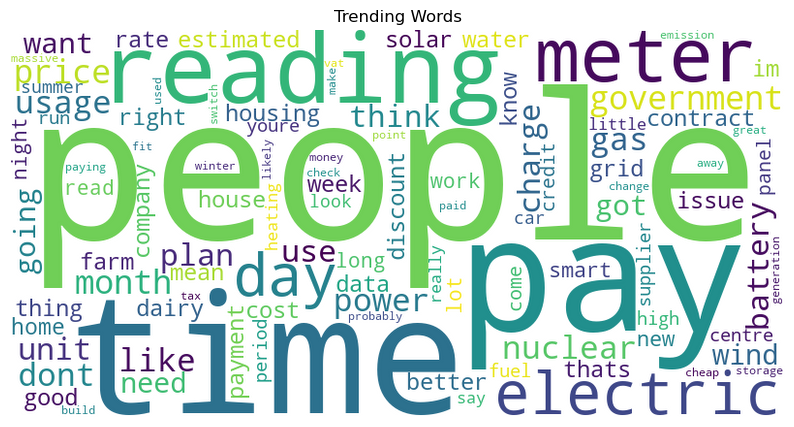

In [51]:
# Generate Word Cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Create a dictionary of word and count
word_freq_dict = dict(zip(top_words['word'], top_words['count']))

# Generate word cloud
wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',  
    max_words=100  # show only top 100 frequent words
).generate_from_frequencies(word_freq_dict)

# Display
plt.figure(figsize=(10, 6))
plt.imshow(wc, interpolation='lanczos')
plt.axis('off')
plt.title('Trending Words')
plt.show()

## Sentiment Analysis using Flair

In [54]:
# Clean data necessary for Flair
sentiments_df['cleaned']=sentiments_df.comment.apply(custom_preprocessor)

# Check length of words, remove rows with comment length below 10 words
sentiments_df=sentiments_df.loc[sentiments_df['cleaned'].apply(lambda x: len(x.split()) > 10)]

In [56]:
# Install Flair
# !pip install flair

In [58]:
# Load text classifier in english
classifier = TextClassifier.load('en-sentiment')

# Import Flair Sentence to process input text
from flair.data import Sentence

# Import accuracy_score to check performance
from sklearn.metrics import accuracy_score

In [59]:
# Create function to check score and provide equivalent sentiment
def format_output_flair(sentence):
    label = sentence.labels[0]
    if label.value == 'POSITIVE' and label.score > 0.7:
        return("Positive")
    elif label.value == 'NEGATIVE' and label.score > 0.7:
        return("Negative")
    else:
        return("Neutral")

# Create a function to analyze text sentiment using Flair
def analyze_flair(text):
    sentence = Sentence(text)
    classifier.predict(sentence)
    score = sentence.labels[0].score
    value = format_output_flair(sentence)
    return score, value

In [62]:
# Analyze data and store it in the dataframe
sentiments_df['flair_score'], sentiments_df['flair_prediction'] = zip(*sentiments_df['cleaned'].apply(analyze_flair))
sentiments_df.head(5)

,index,country,source,comment,cleaned,flair_score,flair_prediction
1,1540,Germany,1d0ab3a/germany_now_has_so_much_solar_power_th...,There is no information on wikipedia that supp...,there is no information on wikipedia that supp...,0.996253,Negative
2,1375,Germany,18pxe9v/almost_52_of_germanys_gross_electricity/,If you could produce your own electricity rath...,if you could produce your own electricity rath...,0.958172,Negative
3,1211,Germany,qmdxtt/people_of_germany_why_is_your_electrici...,This is simply wrong. Germany is a net exporte...,this is simply wrong germany is a net exporter...,0.999675,Negative
4,1176,Germany,qmdxtt/people_of_germany_why_is_your_electrici...,Bad strategic decisions. I could just play tha...,bad strategic decisions i could just play that...,0.997800,Negative
5,1805,Germany,6aqft4/germany_just_smashed_an_energy_record_g...,Doesn't the army have quite a bit of money inv...,doesnt the army have quite a bit of money inve...,0.995618,Negative


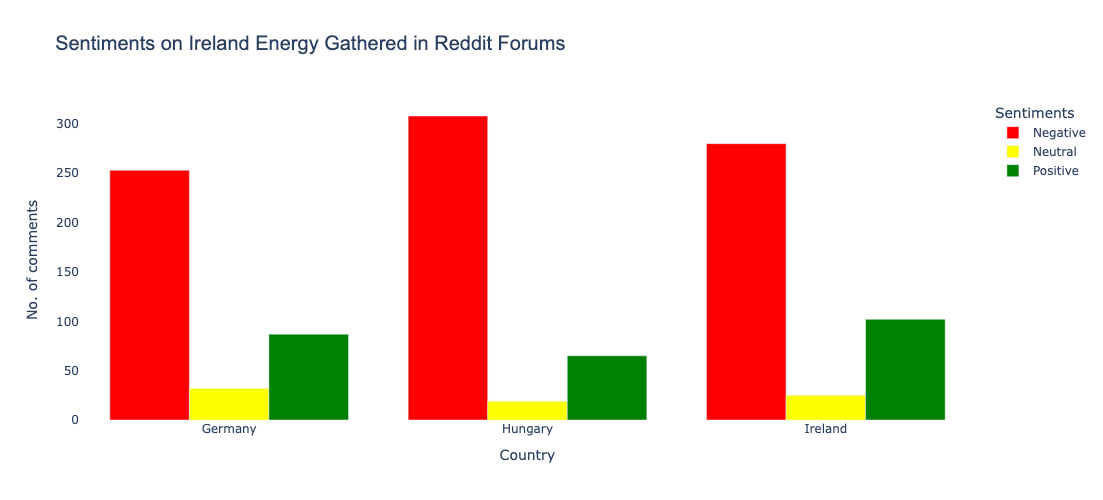

In [114]:
# Define color map
color_map = {
    'Positive': 'green',
    'Negative': 'red',
    'Neutral': 'yellow'
}

grouped_df = sentiments_df.groupby(['country', 'flair_prediction']).size().reset_index(name='count')


# Project Results
fig = px.bar(
    grouped_df,
    x='country', 
    y='count', 
    color='flair_prediction',
    color_discrete_map=color_map,
    labels={
        'count': 'No. of comments',
        'flair_prediction': 'Sentiments',
        'country': 'Country'
    },
    title='Sentiments on Ireland Energy Gathered in Reddit Forums',
    barmode='group'
)


fig.update_layout(
    title_font=dict(size=20, family='Arial'),
    width=900,
    height=500,
    plot_bgcolor='rgba(0,0,0,0)' # this makes background transparent
)

fig.show()

# References


Pandey, P. (2023) The power of NLP with Flair: A comprehensive guide and comparison with other libraries. Medium. Available at: https://medium.com/@pankaj_pandey/the-power-of-nlp-with-flair-a-comprehensive-guide-and-comparison-with-other-libraries-d99875595396 (Accessed: 25 April 2025).

Akbik, A., Bergmann, T., Blythe, D., Rasul, K., Schweter, S. and Vollgraf, R. (2019) FLAIR: An easy-to-use framework for state-of-the-art NLP. Available at: https://github.com/flairNLP/flair (Accessed: 25 April 2025).

Reddit Inc. (2025) 'Reddit API'. Available at: https://www.reddit.com/dev/api (Accessed 13 May 2025).
